In [17]:
print("""
=========================================================
Notebook 2 : Data Preprocessing

Tasks
------
1. Load Dataset
2. Remove unnecessary columns
3. Check Missing Values
4. Handle Missing Values
5. Remove Duplicates
6. Detect Outliers
7. Verify Data Types
8. Save Clean Dataset
=========================================================
""")


Notebook 2 : Data Preprocessing

Tasks
------
1. Load Dataset
2. Remove unnecessary columns
3. Check Missing Values
4. Handle Missing Values
5. Remove Duplicates
6. Detect Outliers
7. Verify Data Types
8. Save Clean Dataset



In [31]:
# Import Required Libraries

import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [32]:
# Load Dataset

df = pd.read_csv("../data/raw/dielectron.csv")

print("Dataset Loaded Successfully")

print("\nDataset Shape :", df.shape)

Dataset Loaded Successfully

Dataset Shape : (100000, 19)


In [48]:
# Remove Extra Spaces from Column Names

df.columns = df.columns.str.strip()

print(df.columns.tolist())

['E1', 'px1', 'py1', 'pz1', 'pt1', 'eta1', 'phi1', 'Q1', 'E2', 'px2', 'py2', 'pz2', 'pt2', 'eta2', 'phi2', 'Q2', 'M']


In [49]:
# Display first five rows

df.head()

,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M
0,58.714,-7.311,10.531,-57.297,12.820,-2.203,2.178,1,11.284,-1.032,-1.881,-11.078,2.145,-2.344,-2.073,-1,8.948
1,6.612,-4.152,-0.580,-5.113,4.192,-1.028,-3.003,-1,17.149,-11.713,5.045,11.465,12.754,0.808,2.735,1,15.893
2,25.542,-11.481,2.042,22.725,11.661,1.420,2.966,1,15.820,-1.473,2.259,-15.589,2.697,-2.455,2.149,1,38.388
3,65.396,7.512,11.887,63.866,14.062,2.218,1.007,1,25.127,4.088,2.596,24.656,4.843,2.330,0.566,-1,3.729
4,61.450,2.953,-14.623,-59.612,14.918,-2.094,-1.372,-1,13.887,-0.278,-2.426,-13.671,2.441,-2.424,-1.685,-1,2.747


In [50]:
# Dataset Information

df.info()

<class 'pandas.DataFrame'>
Index: 99977 entries, 0 to 99999
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   E1      99977 non-null  float64
 1   px1     99977 non-null  float64
 2   py1     99977 non-null  float64
 3   pz1     99977 non-null  float64
 4   pt1     99977 non-null  float64
 5   eta1    99977 non-null  float64
 6   phi1    99977 non-null  float64
 7   Q1      99977 non-null  int64  
 8   E2      99977 non-null  float64
 9   px2     99977 non-null  float64
 10  py2     99977 non-null  float64
 11  pz2     99977 non-null  float64
 12  pt2     99977 non-null  float64
 13  eta2    99977 non-null  float64
 14  phi2    99977 non-null  float64
 15  Q2      99977 non-null  int64  
 16  M       99977 non-null  float64
dtypes: float64(15), int64(2)
memory usage: 13.7 MB


In [51]:
# Check Missing Values

missing_values = df.isnull().sum()

print(missing_values)

E1      0
px1     0
py1     0
pz1     0
pt1     0
eta1    0
phi1    0
Q1      0
E2      0
px2     0
py2     0
pz2     0
pt2     0
eta2    0
phi2    0
Q2      0
M       0
dtype: int64


In [52]:
# Missing Value Percentage

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage

E1     0.000
px1    0.000
py1    0.000
pz1    0.000
pt1    0.000
eta1   0.000
phi1   0.000
Q1     0.000
E2     0.000
px2    0.000
py2    0.000
pz2    0.000
pt2    0.000
eta2   0.000
phi2   0.000
Q2     0.000
M      0.000
dtype: float64

In [53]:
# Handle Missing Values

if df.isnull().sum().sum() == 0:
    print("No Missing Values Found.")
else:
    print("Missing Values Found.")

    # Drop rows where target variable M is missing
    if 'M' in df.columns:
        df.dropna(subset=['M'], inplace=True)

    # Replace remaining missing feature values using median
    df = df.fillna(df.median(numeric_only=True))

    print("Missing Values Handled Successfully.")


No Missing Values Found.


In [54]:
# Duplicate Records

duplicates = df.duplicated().sum()

print("Duplicate Records :", duplicates)

Duplicate Records : 0


In [55]:
# Remove Duplicate Records

df.drop_duplicates(inplace=True)

print("Dataset Shape After Removing Duplicates :", df.shape)

Dataset Shape After Removing Duplicates : (99977, 17)


In [56]:
# Remove Identifier Columns

columns_to_remove = ["Run", "Event"]

df.drop(columns=columns_to_remove, inplace=True)

print("Remaining Columns")

print(df.columns.tolist())

KeyError: "['Run', 'Event'] not found in axis"

In [57]:
# Verify Data Types

df.dtypes

E1      float64
px1     float64
py1     float64
pz1     float64
pt1     float64
eta1    float64
phi1    float64
Q1        int64
E2      float64
px2     float64
py2     float64
pz2     float64
pt2     float64
eta2    float64
phi2    float64
Q2        int64
M       float64
dtype: object

In [58]:
# Statistical Summary

df.describe().T

,count,mean,std,min,25%,50%,75%,max
E1,99977.000,36.436,41.214,0.378,8.457,21.717,50.018,850.602
px1,99977.000,0.136,13.405,-250.587,-5.233,0.141,5.715,134.539
py1,99977.000,0.183,13.471,-126.079,-5.277,0.099,5.648,147.467
pz1,99977.000,-1.511,51.602,-840.987,-15.862,-0.313,13.210,760.096
pt1,99977.000,14.412,12.389,0.220,3.771,12.967,20.019,265.578
eta1,99977.000,-0.064,1.462,-4.165,-1.284,-0.061,1.144,2.623
phi1,99977.000,0.022,1.800,-3.142,-1.527,0.034,1.562,3.141
Q1,99977.000,-0.005,1.000,-1.000,-1.000,-1.000,1.000,1.000
E2,99977.000,44.005,46.753,0.472,11.057,25.265,66.927,948.375
px2,99977.000,-0.003,13.128,-233.730,-4.795,-0.035,4.820,227.330


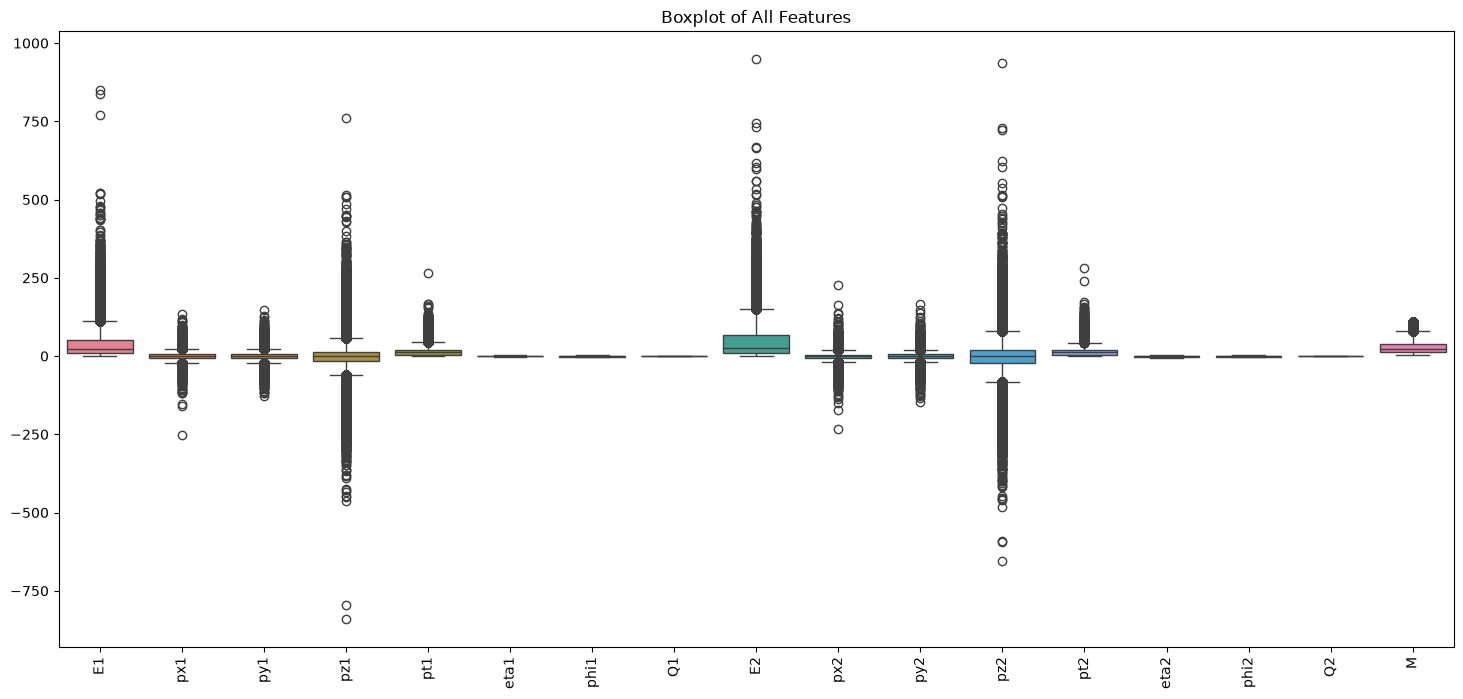

In [59]:
# Boxplots

plt.figure(figsize=(18,8))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.title("Boxplot of All Features")

plt.show()

In [60]:
# Count Outliers using IQR

outlier_summary = {}

for column in df.columns:

    if column != "M":

        Q1 = df[column].quantile(0.25)

        Q3 = df[column].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR

        upper = Q3 + 1.5 * IQR

        count = ((df[column] < lower) | (df[column] > upper)).sum()

        outlier_summary[column] = count

outlier_df = pd.DataFrame(
    outlier_summary.items(),
    columns=["Feature", "Outliers"]
)

outlier_df.sort_values("Outliers", ascending=False)

,Feature,Outliers
3,pz1,19169
11,pz2,16356
10,py2,12238
9,px2,12085
2,py1,9634
1,px1,9337
0,E1,5721
8,E2,3288
12,pt2,3154
4,pt1,2799


In [61]:
print("="*60)

print("Observations")

print("="*60)

print(f"Dataset Shape : {df.shape}")

print()

print(f"Total Missing Values : {df.isnull().sum().sum()}")

print()

print(f"Duplicate Records : {df.duplicated().sum()}")

print()

print("Identifier Columns Removed")

print()

print("Outliers Visualized (Not Removed)")

Observations
Dataset Shape : (99977, 17)

Total Missing Values : 0

Duplicate Records : 0

Identifier Columns Removed

Outliers Visualized (Not Removed)


In [62]:
# Save Clean Dataset

os.makedirs("../data/processed", exist_ok=True)

df.to_csv(
    "../data/processed/dielectron_processed.csv",
    index=False
)

print("Processed Dataset Saved Successfully")

Processed Dataset Saved Successfully


In [63]:
# Verify Saved Dataset

processed_df = pd.read_csv("../data/processed/dielectron_processed.csv")

print(processed_df.shape)

processed_df.head()

(99977, 17)


,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M
0,58.714,-7.311,10.531,-57.297,12.820,-2.203,2.178,1,11.284,-1.032,-1.881,-11.078,2.145,-2.344,-2.073,-1,8.948
1,6.612,-4.152,-0.580,-5.113,4.192,-1.028,-3.003,-1,17.149,-11.713,5.045,11.465,12.754,0.808,2.735,1,15.893
2,25.542,-11.481,2.042,22.725,11.661,1.420,2.966,1,15.820,-1.473,2.259,-15.589,2.697,-2.455,2.149,1,38.388
3,65.396,7.512,11.887,63.866,14.062,2.218,1.007,1,25.127,4.088,2.596,24.656,4.843,2.330,0.566,-1,3.729
4,61.450,2.953,-14.623,-59.612,14.918,-2.094,-1.372,-1,13.887,-0.278,-2.426,-13.671,2.441,-2.424,-1.685,-1,2.747
